(control:examples:optimal-control:inverted-pendulum-on-cart)=
# Inverted pendulum on a cart

## Problem

## Equations of motion with Lagrangian mechanics

### Non-linear equations

Second-order dynamical equation of the mechanical system reads

$$\begin{aligned}
  ( M + m ) \ddot{x} - m \ell \ddot{\theta} \cos \theta + m \ell \dot{\theta}^2 \sin \theta & = F_x - c_x \dot{x} \\
  - m \ell \ddot{x} \cos \theta + m \ell^2 \ddot{\theta} - m g \ell \sin \theta & = C_\theta - c \dot{\theta} \ .
\end{aligned}$$

or at the first order

$$\left\{\begin{aligned}
  \dot{x} & = v \\
  \dot{\theta} & = \omega \\
  (M+m) \, \dot{v} - m \ell \cos\theta \, \dot{\omega} & = - m \ell \omega^2 \sin \theta + F_x - c_x v \\
  - m \ell \cos \theta \, \dot{v} + m \ell^2 \dot{\omega} & = m g \ell \sin \theta + C_\theta - c \omega \ .
\end{aligned}\right.$$

### Linearized equations around equilibria

**Linearized equation around the unstable equilibrium.** First-order system equation around the **unstable equilibium** becomes

$$\begin{aligned}
\begin{bmatrix} M + m & - m \ell \\ -m \ell & m \ell^2 \end{bmatrix} \begin{bmatrix} \ddot{x} \\ \ddot{\theta} \end{bmatrix} +
\begin{bmatrix} c_x & \cdot \\ \cdot & c_\theta \end{bmatrix} \begin{bmatrix} \dot{x} \\ \dot{\theta} \end{bmatrix} +
\begin{bmatrix} \cdot & \cdot \\ \cdot & - m g \ell \end{bmatrix} \begin{bmatrix} \dot{x} \\ \dot{\theta} \end{bmatrix} =
\begin{bmatrix} F_x \\ C_\theta \end{bmatrix} \ .
\end{aligned}$$

or

$$\mathbf{M} \ddot{\mathbf{z}} + \mathbf{C} \dot{\mathbf{z}} + \mathbf{K} \mathbf{z} = \mathbf{f}$$


**State-space (first-order) representation.** With state and input

$$\mathbf{x} = \begin{bmatrix} \mathbf{z} \\ \dot{\mathbf{z}} \end{bmatrix} \quad , \quad \mathbf{u} = \mathbf{f} \ ,$$

the first-order state-space representation of the system reads

$$\left\{\begin{aligned}
 \dot{\mathbf{x}} & = \begin{bmatrix} \cdot & \mathbf{I} \\ -\mathbf{M}^{-1} \mathbf{K} & - \mathbf{M}^{-1} \mathbf{C} \end{bmatrix} \mathbf{x} +
 \begin{bmatrix} \cdot \\ \mathbf{M}^{-1} \end{bmatrix} \mathbf{u} \\
 \mathbf{y} & = \mathbf{C} \mathbf{x} + \mathbf{D} \mathbf{x} \ .
\end{aligned}\right.$$

This the equation we're interested in, when studying the inverted pendulum on a cart.

### Augmented system for tracking reference signal
#> Inverted pendulum plant (linearized) equations
#> Parameters

g = 9.81
m = .1
M = .1
l = .2
cx = 1e-3
ca = 1e-3

#> Matrices of the second-order mechanical system
MM = np.array([[M+m, -m*l], [-m*l, m*l**2]])
MM_inv = np.linalg.inv(MM)
CC = np.array([[cx, .0], [.0, ca]])
KK = np.array([[.0, .0], [.0, -m*g*l]])

#> Matrices of the state-space representation
A = np.block([[np.zeros((2,2)), np.eye(2)], [-MM_inv @ KK, -MM_inv @ CC]])
B = np.block([[np.zeros((2,2))], [MM_inv @ np.array([[1., .0], [.0, 1.]])]])
C = np.block([np.eye(2), np.zeros((2,2))])
D = np.zeros((2,2))

sys = ct.ss(A, B, C, D)
Let $\mathbf{y}_{\text{ref}}$ a reference signal. An augmented system can be defined in order to used optimal control. Let

$$\begin{aligned}
 \dot{\mathbf{x}} & = \mathbf{A} \mathbf{x} + \mathbf{B} \mathbf{u} \\
      \mathbf{y}  & = \mathbf{C} \mathbf{x} + \mathbf{D} \mathbf{u}
\end{aligned}$$

the state-space representation of the plant. Let $\mathbf{y}_{\text{ref}}$ a desired output and the integral error

$$\mathbf{e}_{\text{int}}(t) := \int_{\tau=0}^{t} \left\{ \mathbf{y}(\tau) - \mathbf{y}_{\text{ref}}(\tau) \right\} d \tau \ ,$$

as a new state with dynamical equation

$$\dot{\mathbf{e}}_{\text{int}} = \mathbf{y}(t) - \mathbf{y}_{\text{ref}}(t) = \mathbf{C} \mathbf{x} + \mathbf{D} \mathbf{u} - \mathbf{y}_{\text{ref}} \ .$$

The optimal control is applied to the augmented system

$$\underbrace{\begin{bmatrix} \dot{\mathbf{x}} \\ \dot{\mathbf{e}}_{\text{int}} \end{bmatrix}}_{\dot{\mathbf{z}}} = \underbrace{\begin{bmatrix} \mathbf{A} & \cdot \\ \mathbf{C} & \cdot \end{bmatrix}}_{\hat{\mathbf{A}}} \underbrace{\begin{bmatrix} \mathbf{x} \\ \mathbf{e}_{\text{int}} \end{bmatrix}}_{\mathbf{z}} + \underbrace{\begin{bmatrix} \mathbf{B} \\ \mathbf{D} \end{bmatrix}}_{\hat{\mathbf{B}}_u} \mathbf{u} + \underbrace{\begin{bmatrix} \cdot \\ -\mathbf{I} \end{bmatrix}}_{\hat{\mathbf{B}}_{ref}} \mathbf{y}_{ref}$$

$$\mathbf{y} = \hat{\mathbf{C}} \mathbf{z} + \hat{\mathbf{D}}_u \mathbf{u} \ .$$

Optimal control framework provides the opitmal gain matrix $\hat{\mathbf{K}}$, so that $\mathbf{u} = - \hat{\mathbf{K}} \mathbf{z}$ and the closed loop system becomes

$$\begin{aligned}
  \dot{\mathbf{z}} & = \left( \hat{\mathbf{A}} - \hat{\mathbf{B}}_u \hat{\mathbf{K}} \right) \mathbf{z} + \hat{\mathbf{B}}_{\text{ref}} \mathbf{y}_{\text{ref}} \\
  \mathbf{y} & = \left( \hat{\mathbf{C}} - \hat{\mathbf{D}}_u \mathbf{K} \right) \mathbf{z} \ .
\end{aligned}$$

---

If the output of the system is the angle $\theta(t)$, with reference signal $\mathbf{y}_{\text{ref}} = \theta_{\text{ref}}$, the dynamical system is a SISO system, whose state-space representation is

...



## Libraries

In [1]:
# Install the control library if running in Colab
try:
    import control
except ImportError:
    !pip install control

import numpy as np
import scipy as sp
import control as ct
import matplotlib.pyplot as plt

In [2]:
#> Inverted pendulum plant (linearized) equations
#> Parameters

g = 9.81
m = .1
M = .1
l = .2
cx = 1e-3
ca = 1e-3

#> Matrices of the second-order mechanical system
MM = np.array([[M+m, -m*l], [-m*l, m*l**2]])
MM_inv = np.linalg.inv(MM)
CC = np.array([[cx, .0], [.0, ca]])
KK = np.array([[.0, .0], [.0, -m*g*l]])

#> Matrices of the state-space representation
A = np.block([[np.zeros((2,2)), np.eye(2)], [-MM_inv @ KK, -MM_inv @ CC]])
B = np.block([[np.zeros((2,2))], [MM_inv @ np.array([[1., .0], [.0, 1.]])]])
C = np.block([np.eye(2), np.zeros((2,2))])
D = np.zeros((2,2))

sys = ct.ss(A, B, C, D)

In [3]:
#> Augmented system for reference input
# dx     = A x + B u
# dz = e =   y[0] - yref = C[0,:] x + D[0,:] u - yref
#  y     =   x
# d [ x ] = [ A        . ][ x ] + [ B       ] u + [ . ] yref
#   [ z ]   [ C[:2,:]  . ][ z ]   [ D[:2,:] ]     [-I ]

Aa = np.block([
    [      A, np.zeros((4, 2))],
    [C[:2,:], np.zeros((2, 2))]
])
Ba = np.block([
    [B],
    [D[:2,:]]
])
Ca = np.block([
    [C, np.zeros((2,2))]
])
Da = np.zeros((2,2))

sys_aug = ct.ss(Aa, Ba, Ca, Da)

evals = ct.poles(sys_aug)
print(evals)

AttributeError: module 'control' has no attribute 'poles'

## Control

### Full-state feedback

AttributeError: module 'control' has no attribute 'poles'

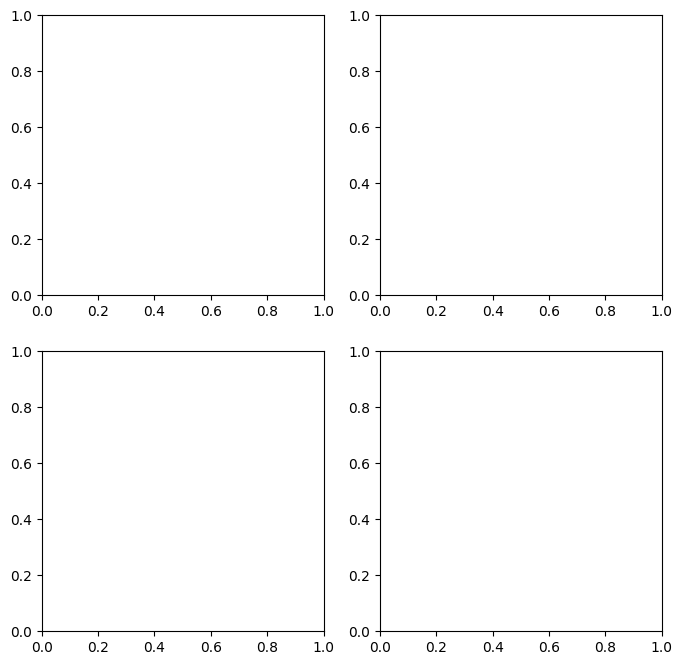

In [4]:
# LQR Weights
Q = np.diag([10, 10, 1, 1, 10, 10]) #

R = np.diag([10, 10])
# R_values = np.linspace(0.001, .01, 4)  # [0.001, 0.01, 0.1]
# R_values = np.logspace(-4, 4, 9)

omega_freq = np.logspace(-2, 2, 1000)

fig, ax = plt.subplots(2,2, figsize=(8, 8))

# for R in R_values:

# Compute LQR Gain
# K, S, E = ct.lqr(A, B, Q, R)
Ka, Sa, Ea = ct.lqr(sys_aug, Q, R)

# #> Loop transfer function L(s) = K * (sI - A)^-1 * B
# #> Open-loop TF, L(s) = G(s) R(s), with R(s) = K
# # from the error to the output
# A_ol = np.block([
#     [     A - B @ Ka[:,:2], - B @ Ka[:,2:]],
#     [      np.zeros((1,2)), np.zeros((1, 1))]
# ])
# B_ol = np.block([[.0], [.0], [1.]])
# C_ol = np.block([[ C - D @ Ka[:,:2], - D @ Ka[:,2]]])
# D_ol = np.zeros((1,1))
# sys_ol = ct.ss(A_ol, B_ol, C_ol, D_ol)

#> Closed-loop TF
# from the disturbance signal to the output
# Simulate closed-loop response with reference input
A_cl = Aa - Ba @ Ka
B_ref = np.block([[np.zeros((4,2))], [-np.eye(2)]])
# C_cl = np.block([[np.eye(2), np.zeros((2,4))]])
# D_cl = np.zeros((2, 2))
C_cl = np.eye(6)
D_cl = np.zeros((6,2))

sys_cl = ct.ss(A_cl, B_ref, C_cl, D_cl)

evals_cl = ct.poles(sys_cl)

# #> Frequency response
# mag_L, phase_L, omega_L = ct.frequency_response(sys_ol, omega_freq)

#> Plots
# #> Bode plots (first line) of L(s)
# ax[0,0].loglog(omega_L, mag_L, label=f'R={R}')
# ax[0,1].semilogx(omega_L, np.degrees(phase_L), label=f'R={R}')
# #> Nyquist diagram of L(s)
# ax[1,0].plot(mag_L*np.cos(phase_L), mag_L*np.sin(phase_L), label=f'R={R}')
#> Eigenvalues of the closed-loop system
ax[1,1].plot(np.real(evals_cl), np.imag(evals_cl), 'x', label=f'R={R}')

#> Critical point and circle in Nyquist plot
theta_v = np.linspace(0, 2*np.pi, 100)
# ax[1,0].plot([-1], [0], 'o', ms=5, color="black")
# ax[1,0].plot(np.cos(theta_v), np.sin(theta_v), '--', color="black")

# #> Formatting plots
# ax[0,0].set_title('Bode Magnitude'); ax[0,0].grid(True); ax[0,0].legend()
# ax[0,1].set_title('Bode Phase'); ax[0,1].grid(True)
# ax[1,0].set_title('Nyquist Plot'); ax[1,0].grid(True); ax[1,0].set_aspect('equal'); ax[1,0].set_xlim([-5, 5]); ax[1,0].set_ylim([-5, 5])
ax[1,1].set_title('Eigenvalues of the closed-loop TF'); ax[1,1].grid(True); ax[1,1].set_aspect('equal')
ax[1,1].set_xlim([-5.5, .5]); ax[1,1].set_ylim([-3., 3.])

fig.set_tight_layout(True)

print(evals_cl)

plt.show()

### Feed-back on state estimate

#### Observer design

System equations, without disturbances/noise

$$\left\{\begin{aligned}
  \dot{\mathbf{x}} & = \mathbf{A} \mathbf{x} + \mathbf{B} \mathbf{u} \\
  \mathbf{y} & = \mathbf{C} \mathbf{x} + \mathbf{D} \mathbf{u} \ ,
\end{aligned}\right.$$

Observer (state estimator) equations

$$\left\{\begin{aligned}
  \hat{\mathbf{y}} & = \mathbf{C} \hat{\mathbf{x}} + \mathbf{D} \mathbf{u} \\
  \dot{\hat{\mathbf{x}}} & = \mathbf{A} \hat{\mathbf{x}} + \mathbf{B} \mathbf{u} + \mathbf{L} \left( \mathbf{y} - \hat{\mathbf{y}} \right) \\
  & = \left( \mathbf{A} - \mathbf{L} \mathbf{C} \right) \hat{\mathbf{x}} + \mathbf{L} \mathbf{C} \mathbf{x} + \mathbf{B} \mathbf{u} \ ,
\end{aligned}\right.$$

so that the dynamical equation of the error $\boldsymbol\varepsilon := \hat{\mathbf{x}} - \mathbf{x}$ reads

$$\dot{\boldsymbol\varepsilon} = \left( \mathbf{A} - \mathbf{L} \mathbf{C} \right) \boldsymbol\varepsilon \ .$$

The dynamical equations of the augmented system, plant+observer, reads

$$\begin{bmatrix} \dot{\mathbf{x}} \\ \dot{\boldsymbol\varepsilon} \end{bmatrix} = \begin{bmatrix} \mathbf{A} & \mathbf{0} \\ \mathbf{0} & \mathbf{A} - \mathbf{L} \mathbf{C} \end{bmatrix} \begin{bmatrix} \mathbf{x} \\ \boldsymbol\varepsilon \end{bmatrix} +  \begin{bmatrix} \mathbf{B} \\ \mathbf{0} \end{bmatrix} \mathbf{u} \ ,$$

and the observer design here is the design of a matrix $\mathbf{L}$ that makes the dynamics of the error $\boldsymbol\varepsilon$, and thus the matrix $\mathbf{A} - \mathbf{L} \mathbf{C}$, asymptotically stable.



#### Control design

Control design is performed as the state is known, and then applied to the estimated state $\hat{\mathbf{x}} = \mathbf{x} + \boldsymbol\varepsilon$, as $\mathbf{u} = - \mathbf{K} \hat{\mathbf{x}}$.

Here the state is augmented with an integrator

$$\mathbf{e}_{\text{int}}(t) := \int_{\tau=0}^{t} \{ \mathbf{y}(\tau) - \mathbf{y}_{\text{ref}}(\tau) \} d \tau \ ,$$

to get tracking of slow signals and then the state of the augmented system is $\mathbf{z} = \begin{bmatrix} \mathbf{x} \\ \mathbf{e}_{\text{int}} \end{bmatrix}$, and optimal control produces a feedback on the augmented state

$$\mathbf{u} = - \mathbf{K} \mathbf{z} = - \mathbf{K}_{\mathbf{x}} \mathbf{x} - \mathbf{K}_{\mathbf{e}} \mathbf{e}_{\text{int}} \ .$$

The integral error can be measured and needs no observer. Thus, the feedback on the observed state becomes

$$\mathbf{u} = - \mathbf{K}_{\mathbf{x}} \hat{\mathbf{x}} - \mathbf{K}_{\mathbf{e}} \mathbf{e}_{\text{int}} \ .$$

#### Combination observer + controller

State-space representation of the open-loop system from the tracking error $\mathbf{e}$ to the output $\mathbf{y}$ reads

$$\left\{\begin{aligned}
  \dot{\mathbf{x}} & = \mathbf{A} \mathbf{x} + \mathbf{B} \mathbf{u} \\
  \mathbf{y} & = \mathbf{C} \mathbf{x} + \mathbf{D} \mathbf{u} \\
  \dot{\boldsymbol\varepsilon} & = \left( \mathbf{A} - \mathbf{L} \mathbf{C} \right) \boldsymbol\varepsilon \\
  \dot{\mathbf{e}}_{\text{int}} & = \mathbf{e} = \mathbf{y} - \mathbf{y}_{\text{ref}} = \mathbf{C} \mathbf{x} + \mathbf{D} \mathbf{u} - \mathbf{y}_{\text{ref}} \\
\end{aligned}\right.$$

$$\hat{\mathbf{x}} = \mathbf{x} + \boldsymbol\varepsilon$$

$$\begin{aligned}
  \mathbf{u}
  & = - \mathbf{K}_{\mathbf{x}} \hat{\mathbf{x}} - \mathbf{K}_{\mathbf{e}} \mathbf{e}_{\text{int}} \\
  & = - \mathbf{K}_{\mathbf{x}} \mathbf{x} - \mathbf{K}_{\mathbf{x}} \boldsymbol\varepsilon - \mathbf{K}_{\mathbf{e}} \mathbf{e}_{\text{int}} \\
\end{aligned}$$

The **open-loop system** reads

$$\begin{aligned}
\begin{bmatrix} \dot{\mathbf{x}} \\ \dot{\boldsymbol\varepsilon} \\ \dot{\mathbf{e}}_{\text{int}} \end{bmatrix} & = \begin{bmatrix} \mathbf{A} & \cdot & \cdot \\ \cdot & \mathbf{A} - \mathbf{L} \mathbf{C} & \cdot \\ \mathbf{C} & \cdot & \cdot \end{bmatrix} \begin{bmatrix} \mathbf{x} \\ \boldsymbol\varepsilon \\ \mathbf{e}_{\text{int}} \end{bmatrix} + \begin{bmatrix} \mathbf{B} \\ \cdot \\ \mathbf{D} \end{bmatrix} \mathbf{u} + \begin{bmatrix} \cdot \\ \cdot \\ - \mathbf{I} \end{bmatrix} \mathbf{y}_{\text{ref}} \\
\mathbf{y} & = \begin{bmatrix} \mathbf{C} & \cdot & \cdot \end{bmatrix} \begin{bmatrix} \mathbf{x} \\ \boldsymbol\varepsilon \\ \mathbf{e}_{\text{int}} \end{bmatrix} + \mathbf{D} \mathbf{u}
\end{aligned}$$

while the **closed-loop system** becomes

$$\begin{aligned}
\begin{bmatrix} \dot{\mathbf{x}} \\ \dot{\boldsymbol\varepsilon} \\ \dot{\mathbf{e}}_{\text{int}} \end{bmatrix} & = \begin{bmatrix} \mathbf{A}-\mathbf{B}\mathbf{K}_{\mathbf{x}} & -\mathbf{B}\mathbf{K}_{\mathbf{x}} & -\mathbf{B}\mathbf{K}_{\mathbf{e}} \\ \cdot & \mathbf{A} - \mathbf{L} \mathbf{C} & \cdot \\ \mathbf{C}-\mathbf{D}\mathbf{K}_{\mathbf{x}} & -\mathbf{D}\mathbf{K}_{\mathbf{x}} & -\mathbf{D}\mathbf{K}_{\mathbf{e}} \end{bmatrix} \begin{bmatrix} \mathbf{x} \\ \boldsymbol\varepsilon \\ \mathbf{e}_{\text{int}} \end{bmatrix}  + \begin{bmatrix} \cdot \\ \cdot \\ - \mathbf{I} \end{bmatrix} \mathbf{y}_{\text{ref}} \\
\mathbf{y} & = \begin{bmatrix} \mathbf{C}-\mathbf{D}\mathbf{K}_{\mathbf{x}} & -\mathbf{D}\mathbf{K}_{\mathbf{x}} & -\mathbf{D}\mathbf{K}_{\mathbf{e}} \end{bmatrix} \begin{bmatrix} \mathbf{x} \\ \boldsymbol\varepsilon \\ \mathbf{e}_{\text{int}} \end{bmatrix} \ .
\end{aligned}$$

If the system has no direct influence of input on measurement output, i.e. $\mathbf{D} = \mathbf{0}$, the system is triangular.

#### State estimator with process and measurement noise

$$\left\{\begin{aligned}
  \dot{\mathbf{x}} & = \mathbf{A} \mathbf{x} + \mathbf{B} \mathbf{u} + \mathbf{B}_d \mathbf{d}\\
  \mathbf{y} & = \mathbf{C} \mathbf{x} + \mathbf{D} \mathbf{u} + \mathbf{D}_d \mathbf{d} + \mathbf{D}_r \mathbf{r} \ ,
\end{aligned}\right.$$

The state estimator problem with $\mathbf{D}_d = \mathbf{0}$ and $\mathbf{D}_\mathbf{r} = \mathbf{I}$ can be solved with the function $\texttt{lqe}$ of the $\texttt{control}$ library,

$$\begin{aligned}
 & \texttt{control.lqe(sys, Edd, Err, Edr)} \\
 & \texttt{control.lqe(A, Bd, C, Edd, Err, Edr)} \\
\end{aligned}$$

In [5]:
#> Optimal state estimator
Edd = .1 * np.eye(2)        # Process noise covariance
Err = .1 * np.eye(2)        # Measurement noise covariance

# If Edd = .01 * np.eye(2) ct.lqe() function returns an error,
# returning "non symmetric QN - i.e. Edd - matrix". There's no
# way to make it see as symmetric...

#> Method 1.
Bd = B.copy()
L, P, E = ct.lqe(A, Bd, C, Edd, Err)

print(L)

"""
#> Method 2.
# Use LQR duality: lqe(A, B, C, V, W) is dual to lqr(A.T, C.T, V, W)
# Note: we use C.T because it replaces B in the dual problem
L_transposed, P, E = ct.lqr(A.T, C.T, V, W)

# The actual observer gain is the transpose of the 'feedback' result
L = L_transposed.T
"""

[[  3.44960563   3.08045383]
 [  3.08045383  34.19623533]
 [ 10.69448739  58.84138659]
 [ 57.12488834 589.43585336]]


"\n#> Method 2.\n# Use LQR duality: lqe(A, B, C, V, W) is dual to lqr(A.T, C.T, V, W)\n# Note: we use C.T because it replaces B in the dual problem\nL_transposed, P, E = ct.lqr(A.T, C.T, V, W)\n\n# The actual observer gain is the transpose of the 'feedback' result\nL = L_transposed.T\n"

In [6]:
#> Optimal controller
# R = 1e-4
# Ka, Sa, Ea = ct.lqr(sys_aug, Q, R)

A_cl_obs = np.block([
    [ A - B @ Ka[:,:4], - B @ Ka[:,:4],   - B @ Ka[:,4:]],
    [  np.zeros((4,4)),      A - L @ C, np.zeros((4, 2))],
    [ C - D @ Ka[:,:4], - D @ Ka[:,:4],   - D @ Ka[:,4:]]
])
B_cl_obs = np.block([[np.zeros((4,2))], [np.zeros((4,2))], [-np.eye(2)]])
C_cl_obs = np.block([ C - D @ Ka[:,:4], - D @ Ka[:,:4], - D @ Ka[:,4:]])
D_cl_obs = np.zeros((2, 2))

sys_cl_obs = ct.ss(A_cl_obs, B_cl_obs, C_cl_obs, D_cl_obs)

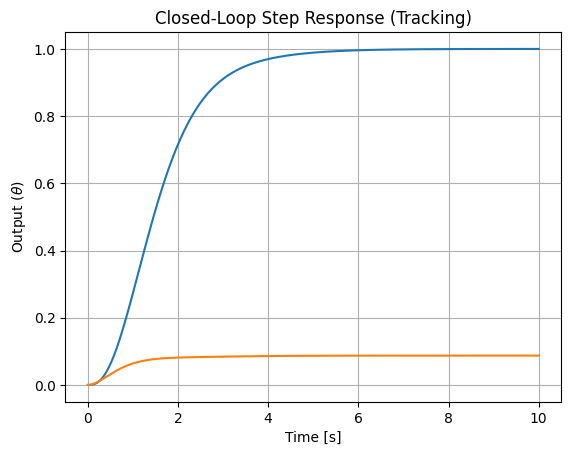

In [7]:
# Time vector
t = np.linspace(0, 10, 1000)

# Step response
# sys_cl is the system from your code (A_cl_obs, B_cl_obs, C_cl_obs, D_cl_obs)
# t_step, y_step = ct.step_response(sys_cl_obs, T=t)

theta_ref_deg = 5.
theta_ref = np.deg2rad(theta_ref_deg)
x_ref = 1.

timepts = t.copy()
inputs = [ np.ones(len(t)) * x_ref, np.ones(len(t)) * theta_ref ]

t_step, y_step = ct.forced_response(sys_cl_obs, timepts, inputs)

plt.figure()
plt.plot(t_step, y_step.T)
plt.title('Closed-Loop Step Response (Tracking)')
plt.xlabel('Time [s]')
plt.ylabel(r"Output ($\theta$)")
plt.grid(True)

In [8]:
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# solve_ivp(fun, t_span, y0, method="RK45", ..., args=tuple)

# fun(t, z, args=tuple)
def f(t, z, args):
    """
    State, z = [ x, vareps, e_int ]
    """

    #> args is supped to be a 1-element tuple with a dict
    args_di = args

    #> System parameters
    g, l = args_di["g"], args_di["l"]
    m, M = args_di["m"],  args_di["M"]
    cx, ca = args_di["cx"], args_di["ca"]

    #> Linearized system matrices
    A, B, C, D = args_di["A"], args_di["B"], args_di["C"], args_di["D"]

    #> Optimal control matrix
    Kx, Ke = args_di["Kx"], args_di["Ke"]
    #> State-estimator L matrix
    L = args_di["L"]

    #> Reference input: select the proper y_ref for the current time 't'
    y_ref_func = args_di["y_ref_func"]
    yref = y_ref_func(t) # Interpolates to get the value at time t
    # pos_ref, angle_ref = yref[0], yref[1]

    #> Motor physical limits
    motor_clipping = args_di["motor_clipping"]
    u_max = args_di["u_max"]

    #> State variables
    x, th, v, om, eps, e_int = z[0], z[1], z[2], z[3], z[4:8], z[8:]
    state = z[:4]

    #> Feed-back control
    u = - Kx @ state - Kx @ eps - Ke @ e_int

    if ( motor_clipping ):
        u = np.clip(u, -u_max, u_max)

        #> Need for anti-windup
        # if (u_ideal > u_max and (C @ x + D @ u - yref) > 0) or (u_ideal < -u_max and (C @ x + D @ u - yref) < 0):
        #     de_int = 0 # Stop integrating...
        # else:
        #     de_int = C @ x + D @ u - yref

    M_vel = np.array([
         [            M+m, -m*l*np.cos(th)],
         [-m*l*np.cos(th),          m*l**2]
    ])

    dx     = v
    dth    = om
    d_vel  = np.linalg.inv(M_vel) @ \
             np.array([
                  [-m*l*om**2*np.sin(th) + u[0] - cx*v],
                  [ m*g*l*np.sin(th) + u[1] - ca*om]
             ])
    deps   = ( A - L @ C ) @ eps
    de_int = C @ state + D @ u - yref

    return np.concatenate(([dx], [dth], d_vel.ravel(), deps, de_int))

In [9]:
#> Reference signal
t_span = [0, 20]
t_eval = np.linspace(t_span[0], t_span[1], 200)
ref_theta_values = np.where(t_eval < 10, np.radians(0), np.radians(5))

# Transition settings
start_time = 5
duration = 3
end_time = start_time + duration
start_val = 0
end_val = 2
ref_x_values = np.piecewise(t_eval,
    [t_eval < start_time, (t_eval >= start_time) & (t_eval <= end_time), t_eval > end_time],
    [start_val,
     lambda t: start_val + (end_val - start_val) * (t - start_time) / duration,
     end_val]
)

y_ref_values = np.column_stack((ref_x_values, ref_theta_values))

#> Create an interpolator to pass to the solve_ivb function
y_ref_func = interp1d(t_eval, y_ref_values, axis=0, kind='linear', fill_value="extrapolate")

In [10]:
# 1. Bundle all parameters into the dictionary
sim_config = {
    "g": 9.81, "l": l, "m": m, "cx": cx,      # Example physical params
    "M": M, "ca": ca,
    "A": A, "B": B, "C": C,  "D": D,          # Linearized matrices
    "Kx": Ka[:, :4], "Ke": Ka[:, 4:],         # Optimal gains (Kx is 1x2, Ke is 1x1)
    "L": L,                                   # Observer gain
    "y_ref_func": y_ref_func,                 # Ref input interpolator function
    "motor_clipping": False, "u_max": .05     # Motor clippint
}

# 2. Set Initial Conditions [x, theta, v, omega, eps_theta, eps_omega, e_int]
# Example: System starts at 2 degrees, observer thinks it's at 0
# Error is defined to be eps = x_hat - x
z0 = [2., np.radians(10), .0, .0, -2., -np.radians(10), .0, .0, .0, .0]

# 3. Execute the simulation
from scipy.integrate import solve_ivp
sol = solve_ivp(
    f,
    t_span,
    z0,
    args=(sim_config,),
    t_eval=t_eval,
    method='BDF'      # Default: "RK45" very slow for stiff problems(?)
)

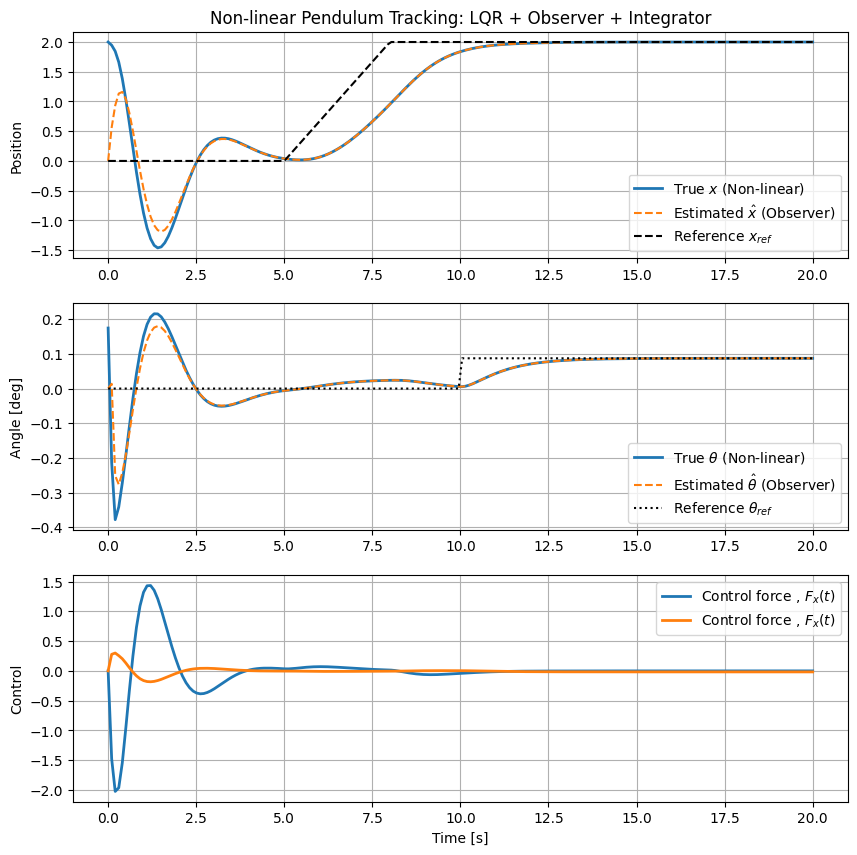

In [11]:
import matplotlib.pyplot as plt

#> Output and control effort
fig, ax = plt.subplots(3, 1, figsize=(10, 10))

#> Estimation error, eps = x_hat - x, x_hat = x + eps
hat_x     = sol.y[0] + sol.y[4]
hat_theta = sol.y[1] + sol.y[5]

# Plot True Pendulum Angle (convert back to degrees)
ax[0].plot(sol.t, sol.y[0]       , label='True $x$ (Non-linear)', linewidth=2)                      # output
ax[0].plot(sol.t, hat_x    , '--', label='Estimated $\\hat{x}$ (Observer)')                         # estimated output
ax[0].plot(sol.t, y_ref_func(sol.t)[:,0], '--', color="black", label=r'Reference $x_{ref}$')        # reference

ax[1].plot(sol.t, sol.y[1]       , label='True $\\theta$ (Non-linear)', linewidth=2)                # output
ax[1].plot(sol.t, hat_theta, '--', label='Estimated $\\hat{\\theta}$ (Observer)')                   # estimated output
ax[1].plot(sol.t, y_ref_func(sol.t)[:,1], ':' , color="black", label=r'Reference $\theta_{ref}$')   # reference

ax[0].set_title("Non-linear Pendulum Tracking: LQR + Observer + Integrator")
ax[0].set_ylabel("Position")
# ax[0].set_xlabel("Time [s]")
ax[1].set_ylabel("Angle [deg]")

u = -Ka[:,:4] @ sol.y[0:4] - Ka[:,:4] @ sol.y[4:8] - Ka[:,4:] @ sol.y[8:]
ax[2].plot(sol.t, u[0], label=r"Control force , $F_x(t)$", linewidth=2)      # output
ax[2].plot(sol.t, u[1], label=r"Control force , $F_x(t)$", linewidth=2)      # output
ax[2].set_ylabel("Control")
ax[2].set_xlabel("Time [s]")

ax[0].legend();  ax[0].grid()
ax[1].legend();  ax[1].grid()
ax[2].legend();  ax[2].grid()

plt.show()

#>